# Assignment 3 - PHYS 7332 Network Science Data 2

Daniel Uriel González Quezada

In [73]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import pickle as pkl
import math
import matplotlib.animation as animation
from communities.algorithms import louvain_method
import random


from joblib import Parallel, delayed
#import community as community_louvain

## Problem 1 - Community detection, degree heterogeneity, and graph-tool

### Solution using Louvain method for getting highest modularity

In [41]:
sizes = list(range(50,301,50))
m_s = list(range(1,6))
modularities = np.zeros((6, 5))

for i, size in enumerate(sizes):
    for j, m in enumerate(m_s):
        G = nx.barabasi_albert_graph(size, m)
        A = nx.to_numpy_array(G)
        partition, _ = louvain_method(A)
        modularities[i,j] = nx.community.modularity(G, partition)

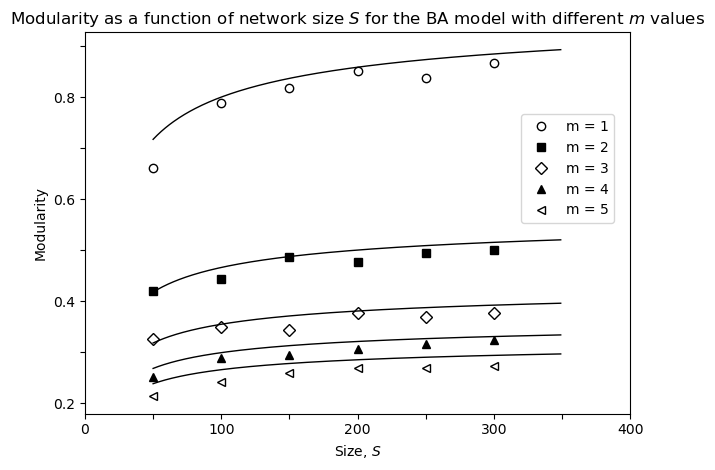

In [101]:
markers = ["<", "^", "D", "s", "o"]; markers = markers[::-1]

a = 0.165

def ansatz(S):
    return (a+(1-a)/m)*(1-2/np.sqrt(S))

S_range = np.arange(50, 350, 1)
ansatz_curves = []
for m in m_s:
    ansatz_curves.append(ansatz(S_range))

for i, a in enumerate(modularities.T):
    plt.plot(sizes, a, markers[i], markerfacecolor="white" if i%2==0 else "black", markeredgecolor="black", linestyle="None", label=f"m = {m_s[i]}")
    plt.plot(S_range, ansatz_curves[i], color="black", linewidth=1)
plt.xlabel("Size, $S$")
plt.ylabel("Modularity")
plt.xlim(0, 400)
plt.xticks(range(0,401,50), [0, "", 100, "", 200, "", 300, "", 400])
plt.yticks(np.arange(0.2, 0.91, 0.1), [0.2, "", 0.4, "", 0.6, "", 0.8, ""])
plt.legend(loc=(0.8,0.5))
plt.title("Modularity as a function of network size $S$ for the BA model with different $m$ values")
plt.tight_layout()
plt.show()

The main result in the paper shows that modularity can result from fluctuations in the link establishment in certain realizations of random graphs. In particular, we can observe that for $m=4$, modularity is close to the highest possible value. The main implication of such a high modularity in random graphs is that it might be harder to compare real networks with null models for community detection. Therefore, it might not be a reliable community structure measure for some network configurations.

### 1.b)

In [31]:
import graph_tool.all as gt
import matplotlib.pyplot as plt

In [6]:
gt.__version__

'2.77 (commit c6a3b9f3, Fri Aug 9 15:03:36 2024 -0300)'

In [35]:
g = gt.collection.data["polblogs"]
g = gt.extract_largest_component(g, directed=False)

state_no_degree_corr = gt.minimize_blockmodel_dl(g, state_args=dict(deg_corr=False), multilevel_mcmc_args=dict(B_min=2, B_max=2))
state_degree_corr = gt.minimize_blockmodel_dl(g, state_args=dict(deg_corr=True), multilevel_mcmc_args=dict(B_min=2, B_max=2))

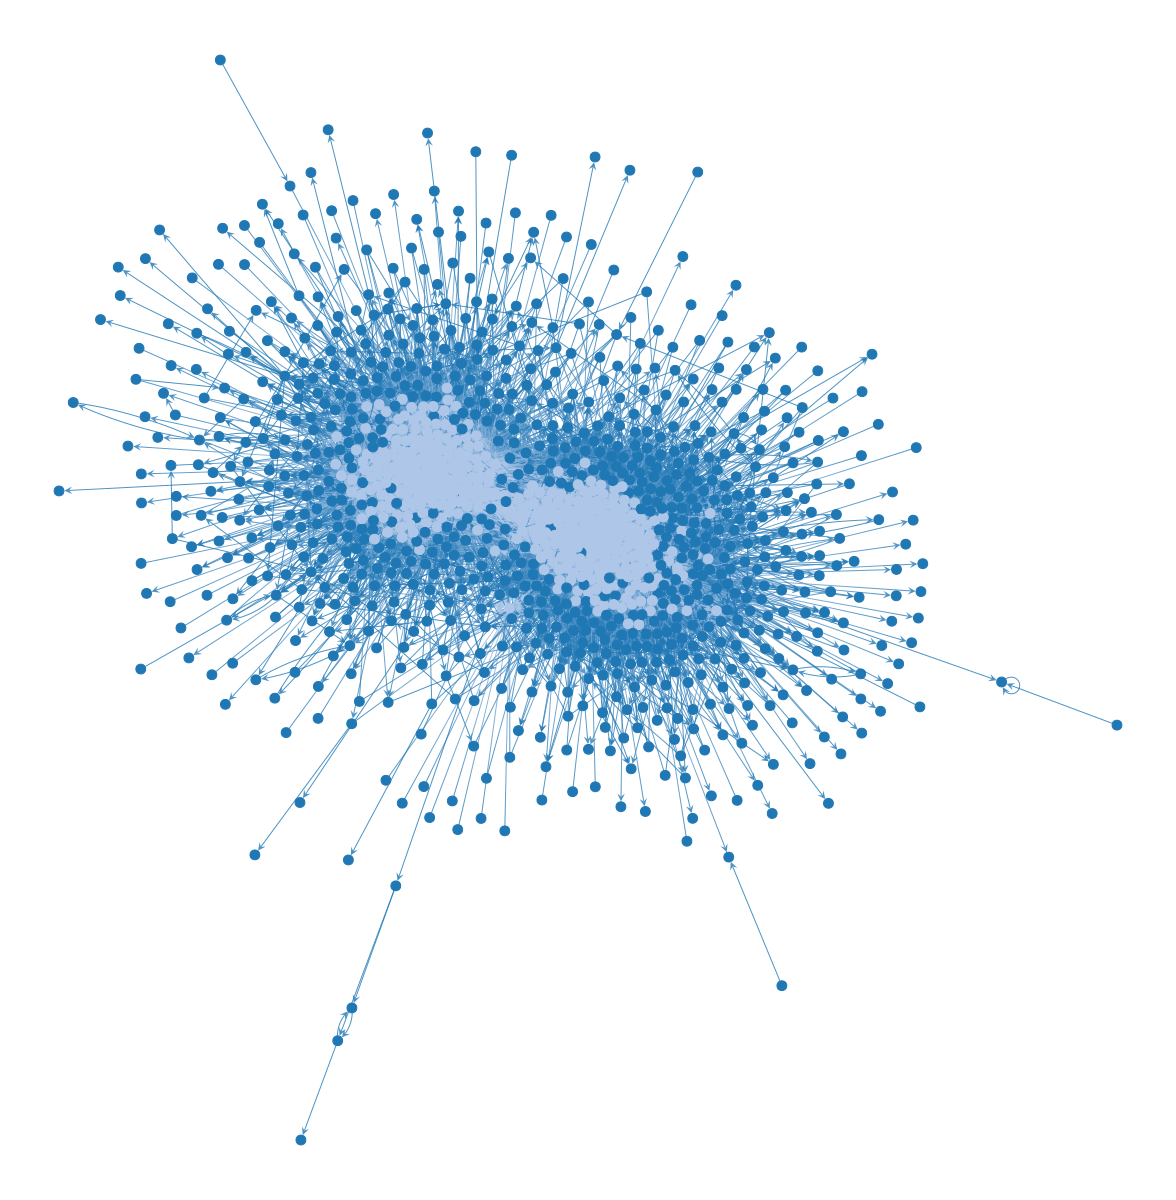

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fe426883890, at 0x7fe426880f80>

In [36]:
state_no_degree_corr.draw()

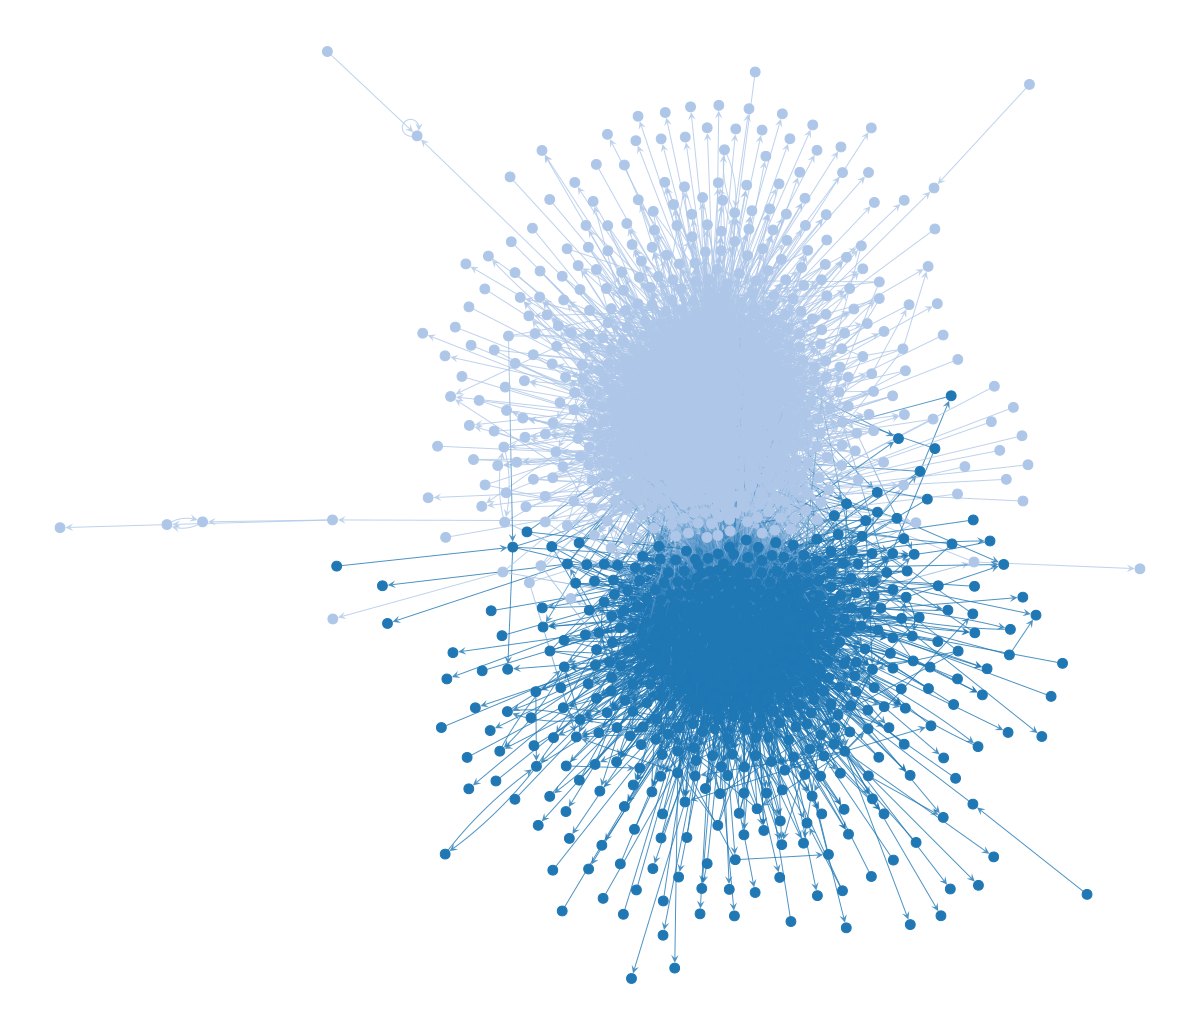

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fe426883890, at 0x7fe4301bf800>

In [37]:
state_degree_corr.draw()

### 1.c)

#### i. Description lenght

In [23]:
print(f"Not degree-corrected {state_no_degree_corr.entropy():.3f}")
print(f"Degree-corrected {state_degree_corr.entropy():.3f}")

Not degree-corrected 83115.974
Degree-corrected 63427.040


### ii.

In [32]:
entropies_ndc = []
entropies_dc = []

state_ndc = gt.BlockState(g, B=2, deg_corr=False)
state_dc = gt.BlockState(g, B=2, deg_corr=True)

for _ in range(1000):
    state_ndc.mcmc_sweep(niter=1)
    entropies_ndc.append(state_ndc.entropy())
    
    state_dc.mcmc_sweep(niter=1)
    entropies_dc.append(state_dc.entropy())

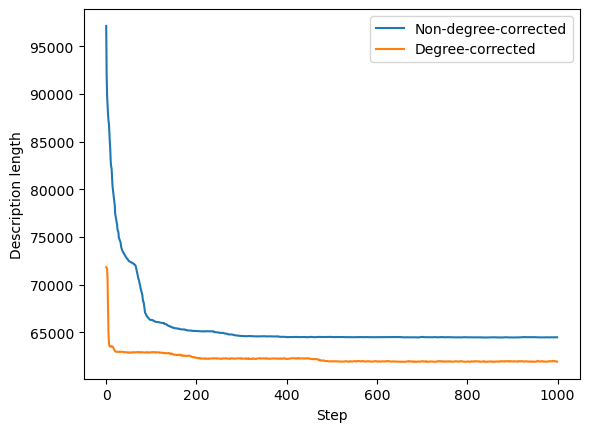

In [34]:
plt.plot(entropies_ndc, label="Non-degree-corrected")
plt.plot(entropies_dc, label="Degree-corrected")
plt.xlabel("Step")
plt.ylabel("Description length")
plt.legend()
plt.show()

We can observe that the degree-corrected variation of the stochastic blockmodel offers, at every step, a shorter description length. As described in VII.A of Peixoto's _Bayesian stochastic blockmodeling_, the most compresive model should be preferred.

## Problem 3 - Random Walk Dynamics

### 3.a)

In [97]:
def commute_time(G, i, j):
    """
    Calculate the number of steps a random walker takes to commute from node `i` to node `j` 
    and return to node `i` in an unweighted, undirected graph.

    This function simulates a random walk from node `i` to node `j` and back. It counts the 
    number of steps required to first reach node `j` from node `i` and then return to `i`.
    If node `j` is isolated (has no neighbors), the function returns "HELP" to indicate that
    the commute is impossible.

    Parameters
    ----------
    G : NetworkX graph
        The input graph representing the network where the commute time is calculated.
    i : int or str
        The starting node for the random walk.
    j : int or str
        The target node for the random walk.

    Returns
    -------
    int
        The number of steps taken to commute from node `i` to node `j` and back to `i`.
    str
        Returns "HELP" if node `j` is isolated, making the commute impossible.

    Notes
    -----
    - If `i` and `j` are the same node, the commute time is zero, as no movement is needed.
    - The function performs a random walk by selecting a neighboring node at each step.
      The commute ends when the random walk returns to the starting node `i` after visiting `j`.
    - This function assumes that all nodes in the graph are accessible from each other.
    """
    # Should this be an average?
    steps = 0
    reached_target = False
    current_node = i
    
    if i == j:
        return steps
    
    while current_node != i or not reached_target:
        neighbors = list(G.neighbors(current_node))
        if len(neighbors) == 0:
            return "HELP"
        next_visit = random.choice(neighbors)
        steps += 1
        current_node = next_visit
        if current_node == j:
            reached_target = True
        
    return steps

In [60]:
G = nx.karate_club_graph()
np.random.seed(31415926)
nodes_to_test = np.random.choice(G.nodes(), size = (3,2), replace=False)

In [76]:
for i, j in nodes_to_test:
    print(f"Commute time between nodes {i} and {j}:", commute_time(G, i, j))

Commute time between nodes 32 and 14: 58
Commute time between nodes 11 and 31: 199
Commute time between nodes 33 and 21: 61


### 3.b)

In [96]:
def mean_commute_time(G, n_reps=100):
    """
    Calculate the mean commute time between all pairs of nodes in a given graph.

    The mean commute time is the expected number of steps a random walker takes to travel
    from node `u` to node `v` and return, averaged over all possible pairs of nodes in the graph.
    This function utilizes parallel processing to efficiently compute the commute times
    between each pair, and then returns the average commute time across all pairs.

    Parameters
    ----------
    G : NetworkX graph
        The input graph on which to calculate mean commute times.
    n_reps : int, optional
        The number of repetitions for each pair of nodes to estimate commute time more accurately.
        Defaults to 100.

    Returns
    -------
    float
        The average commute time across all node pairs in the graph.

    Notes
    -----
    - This function uses parallel computation to speed up the calculation of commute times
      across all pairs of nodes. The `commute_time` function should be designed to compute
      the commute time between two specified nodes.
    - The commute time between each pair of nodes `(u, v)` is calculated using the `commute_time`
      function. The results are then averaged across all pairs for the final output.
    """
    nodes = list(G.nodes)
    n = len(nodes)
    #commute_time_matrix = np.zeros((n,n))
    pairs_of_nodes = permutations(nodes, 2) 
    # Nima's amazing suggestion: parallelize this thing
    all_commute_times = Parallel(n_jobs=-1)(delayed(commute_time)(G, u, v) for u, v in pairs_of_nodes)
    
    #for i,j in pairs_of_nodes:
    #    n_steps = []
    #    for _ in range(n_reps):
    #        n_steps.append(commute_time(G, i, j))
    #    commute_time_matrix[i,j] = np.average(n_steps)
    #    commute_time_matrix[j,i] = commute_time_matrix[i,j]
        
    return np.average(all_commute_times)

In [88]:
er_network_times = []
ba_network_times = []

for _ in range(10):
    size = 500
    avg_deg = 8
    m = 4
    G_er = nx.erdos_renyi_graph(size, avg_deg/(size-1))
    while not nx.is_connected(G_er):
        G_er = nx.erdos_renyi_graph(size, avg_deg/(size-1))
    G_ba = nx.barabasi_albert_graph(size, m)

    er_network_times.append(mean_commute_time(G_er))
    ba_network_times.append(mean_commute_time(G_ba))

In [93]:
print("ER networks:", np.average(er_network_times))
print("BA network:", np.average(ba_network_times))

ER networks: 1365.0900625250501
BA network: 1577.122681763527


We can appreciate that the average commute time is higher in the BA network model.

## Problem 4

In [2]:
import torch
from torch.nn import Linear
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import CitationFull
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import RandomNodeSplit
from sklearn.manifold import TSNE
from threadpoolctl import threadpool_limits

In [3]:
dataset = CitationFull('/courses/PHYS7332.202510/shared/data/', name='Cora')

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device) # yell if you don't see 'cuda' here!

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gcn1 = GCNConv(dataset.num_features, 64) 
        self.gcn2 = GCNConv(64, 16)
        self.out = Linear(16, dataset.num_classes)  
        
    def forward(self, x, edge_index):
        h1 = self.gcn1(x, edge_index).relu()
        h2 = self.gcn2(h1, edge_index).relu()
        z = self.out(h2)
        return h2, z

splits = RandomNodeSplit(split='train_rest', num_val=0.15, num_test=0.15)(dataset.data)

model = GCN() 
model.to(device) 

criterion = torch.nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) 

loader = DataLoader(dataset)


embeddings_per_epoch = {}
# Training
for epoch in range(100):
    model.train() 
    total_loss = 0 
    tot_accuracy = 0
    for batch in loader:
        optimizer.zero_grad() 
        h2, z = model(batch.x.to(device), batch.edge_index.to(device)) 
        loss = criterion(z[splits.train_mask], batch.y.to(device)[splits.train_mask])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    #if epoch % 10 == 0:
    #    h2, _ = model(dataset.x.to(device), dataset.edge_index.to(device))
    #    embeddings_per_epoch[epoch] = h2.cpu().detach().numpy()
    
    model.eval()
    val_h, val_z = model(dataset.x.to(device), dataset.edge_index.to(device)) 
    
    if epoch % 10 == 0:
        embeddings_per_epoch[epoch] = val_h.cpu().detach().numpy()
        
    val_z = val_z[splits.val_mask]
    ans = val_z.argmax(dim=1) 
    
    
        
    ys = batch.y.to(device)[splits.val_mask]
    tot_accuracy += torch.mean(torch.eq(ans, ys).float()) # how often were we right?
    loss = total_loss / len(loader)
    accuracy = tot_accuracy / len(loader)
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}')

cpu


C:\Users\asque\anaconda3\Lib\site-packages\torch_geometric\data\in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


Epoch: 000, Loss: 4.2371, Accuracy: 0.0253
Epoch: 001, Loss: 4.0933, Accuracy: 0.0845
Epoch: 002, Loss: 3.8445, Accuracy: 0.1337
Epoch: 003, Loss: 3.5874, Accuracy: 0.2082
Epoch: 004, Loss: 3.3612, Accuracy: 0.2789
Epoch: 005, Loss: 3.0670, Accuracy: 0.3250
Epoch: 006, Loss: 2.8597, Accuracy: 0.3793
Epoch: 007, Loss: 2.6471, Accuracy: 0.4311
Epoch: 008, Loss: 2.4376, Accuracy: 0.4682
Epoch: 009, Loss: 2.2586, Accuracy: 0.5066
Epoch: 010, Loss: 2.0580, Accuracy: 0.5204
Epoch: 011, Loss: 1.9016, Accuracy: 0.5504
Epoch: 012, Loss: 1.7430, Accuracy: 0.5857
Epoch: 013, Loss: 1.6030, Accuracy: 0.5925
Epoch: 014, Loss: 1.4936, Accuracy: 0.6069
Epoch: 015, Loss: 1.3861, Accuracy: 0.6187
Epoch: 016, Loss: 1.2874, Accuracy: 0.6379
Epoch: 017, Loss: 1.1989, Accuracy: 0.6463
Epoch: 018, Loss: 1.1239, Accuracy: 0.6575
Epoch: 019, Loss: 1.0645, Accuracy: 0.6625
Epoch: 020, Loss: 1.0095, Accuracy: 0.6676
Epoch: 021, Loss: 0.9518, Accuracy: 0.6713
Epoch: 022, Loss: 0.9001, Accuracy: 0.6783
Epoch: 023,

In [8]:
emb_2d = {}
with threadpool_limits(limits=1, user_api='blas'):
    for epoch, embeddings in embeddings_per_epoch.items():
        tsne = TSNE(n_components=2, random_state=42)
        embeddings_2d = tsne.fit_transform(embeddings)
        
        emb_2d[epoch] = embeddings_2d
        #axes.flat[epoch//10].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=dataset.y, cmap='tab10', s=15)
        #plt.colorbar()

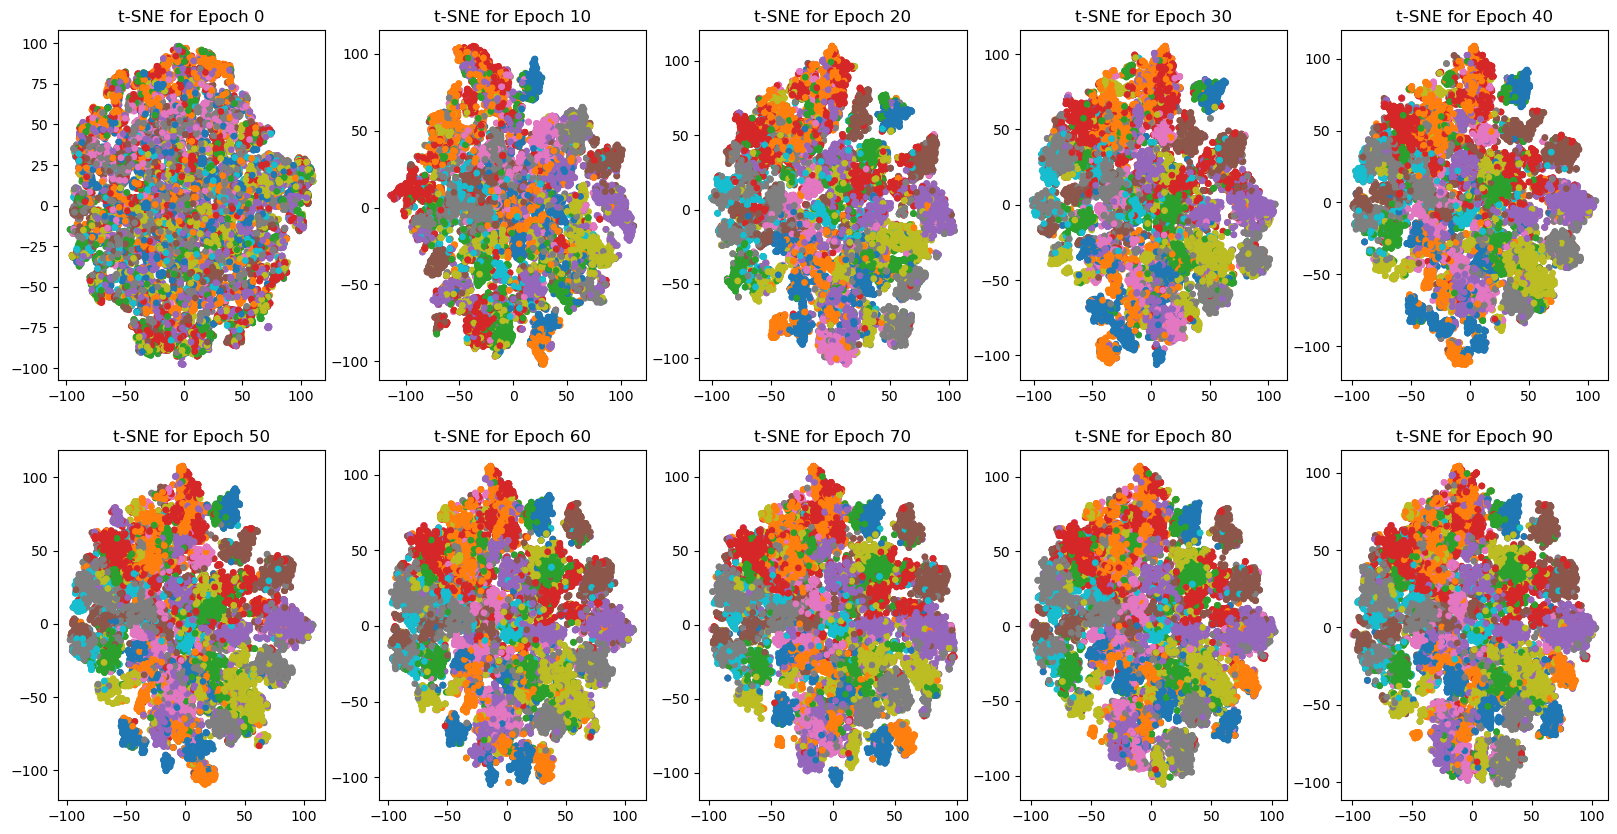

In [32]:
fig, axes = plt.subplots(ncols=5, nrows=2, figsize=(20,10))


for epoch, embedding in emb_2d.items():
    axes.flat[epoch//10].scatter(embedding[:, 0], embedding[:, 1], c=dataset.y, cmap='tab10', s=15)
    axes.flat[epoch//10].set_title(f"t-SNE for Epoch {epoch}")
    artists.append(axes_a.scatter(embedding[:, 0], embedding[:, 1], c=dataset.y, cmap='tab10', s=15))
plt.show()

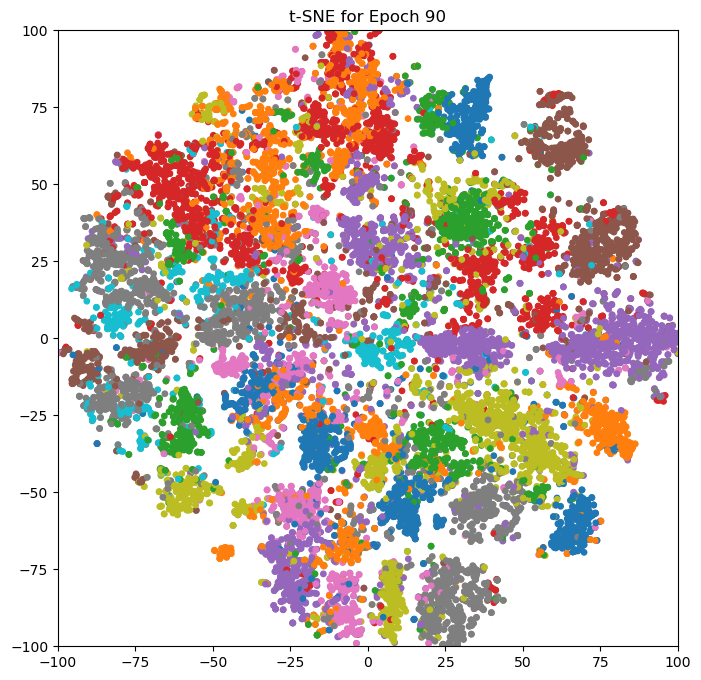

In [94]:
fig, ax = plt.subplots(figsize=(8, 8))

def update(epoch):
    ax.cla()
    
    embedding = emb_2d[epoch]
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=dataset.y, cmap='tab10', s=15)
    
    ax.set_title(f"t-SNE for Epoch {epoch}")
    ax.set_xlim(-100, 100)
    ax.set_ylim(-100, 100)
    
    return scatter,

ani = animation.FuncAnimation(fig, update, frames=list(emb_2d.keys()), blit=True, repeat=False)

ani.save("HW3_Q4.gif", writer='pillow', fps=2)

plt.show()